# 04 – Segmentation Prototype

**Purpose:** Prototype the segmentation stage on centred BGA solder-joint ROIs from notebook 03:
load a U-Net-style model, run inference plumbing, produce binary mask overlays, and compute
crack-fraction values inside a fixed circle mask that envelopes the visible solder joint.

**Corresponds to:** AGENTS.md Step 3.4 and Test Step 4.4

> ⚠️ **Prototype limitation:** this notebook does **not** contain a trained BGA crack model.
> ImageNet encoder weights are not crack-training, and an untrained decoder/head cannot be
> trusted for crack decisions. The notebook validates the mechanics of ROI → solder-joint
> circle mask → crack-candidate mask → crack fraction → overlay. Real accuracy requires
> manual labels and a fine-tuned crack checkpoint.

> **2026-06-28 refinement:** the original prototype used a fixed 105 px radius denominator
> inherited from full-field registration. Human review showed that outline was too large.
> A temporary adaptive mask was tested, but visual review showed a circle better envelopes
> the solder joint, so the notebook now uses a smaller fixed circle denominator.

## 0. Configuration


In [1]:
from pathlib import Path

# ── Edit these to switch package / ROI source ────────────────────────────────
PACKAGE    = "FP11_BLTC"
IMAGE_STEM = "FP11_2_X20"      # uses output/rois/<IMAGE_STEM>/ from notebook 03
# ─────────────────────────────────────────────────────────────────────────────

REPO_ROOT = Path("../..").resolve()
ROI_DIR   = REPO_ROOT / "output" / "rois" / IMAGE_STEM
OVERLAY_DIR = REPO_ROOT / "output" / "segmentation_overlays" / IMAGE_STEM

ROI_SIZE    = 256
# Human-reviewed denominator: smaller than the original 105 px registration radius,
# but intentionally circular because it better envelopes the visible solder joint.
JOINT_RADIUS = 56
SAMPLE_SIZE = 20
RNG_SEED    = 44

# U-Net prototype configuration. Encoder weights are useful for input plumbing,
# but are NOT equivalent to a trained crack segmentation model.
ENCODER_NAME    = "resnet34"
ENCODER_WEIGHTS = "imagenet"
UNET_THRESHOLD  = 0.5
MORPH_KERNEL    = 5

print(f"Package       : {PACKAGE}")
print(f"ROI source    : {ROI_DIR.relative_to(REPO_ROOT)}")
print(f"Overlay output: {OVERLAY_DIR.relative_to(REPO_ROOT)}")
print(f"ROI size      : {ROI_SIZE} × {ROI_SIZE} px")
print(f"Joint radius  : {JOINT_RADIUS} px")
print(f"Sample size   : {SAMPLE_SIZE}")
print(f"U-Net encoder : {ENCODER_NAME} ({ENCODER_WEIGHTS})")

Package       : FP11_BLTC
ROI source    : output\rois\FP11_2_X20
Overlay output: output\segmentation_overlays\FP11_2_X20
ROI size      : 256 × 256 px
Joint radius  : 56 px
Sample size   : 20
U-Net encoder : resnet34 (imagenet)


## 1. Load sample ROIs from notebook 03 output


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert ROI_DIR.exists(), (
    f"ROI directory not found: {ROI_DIR}. "
    "Run src/notebooks/03_roi_extraction.ipynb first to generate inspection ROIs."
)

roi_paths = sorted(ROI_DIR.glob("*.png"))
assert roi_paths, f"No ROI PNGs found in {ROI_DIR}"

records = []
for path in roi_paths:
    roi = cv2.imread(str(path))
    if roi is None:
        continue
    records.append({
        "ball_id": path.stem,
        "path": path,
        "roi": roi,
        "shape": roi.shape,
    })

roi_df = pd.DataFrame(records)
shape_ok = roi_df["shape"].map(lambda s: s == (ROI_SIZE, ROI_SIZE, 3)).all()
assert shape_ok, "One or more ROI samples have unexpected shape."

rng = np.random.default_rng(RNG_SEED)
sample_idx = rng.choice(len(roi_df), size=min(SAMPLE_SIZE, len(roi_df)), replace=False)
sample_records = [roi_df.iloc[int(i)].to_dict() for i in sample_idx]

print(f"Loaded {len(roi_df)} ROI PNGs from {ROI_DIR.relative_to(REPO_ROOT)}")
print(f"All ROI shapes OK: {shape_ok}")
print("Sample IDs:", ", ".join(r["ball_id"] for r in sample_records))


Loaded 50 ROI PNGs from output\rois\FP11_2_X20
All ROI shapes OK: True
Sample IDs: A24, A18, A13, A35, AA1, A38, A23, A16, A29, A31, AA10, A7, A10, A17, A14, A27, A40, A6, A5, A8


## 2. Circle mask, post-processing, and crack-fraction helpers

The denominator should be the **visible solder joint**, not the full 256 px ROI and not the
oversized 105 px circle used only as a conservative ROI-containment estimate in notebook 02.
After visual review, a smaller **fixed circle** is preferred over the temporary adaptive mask
because it better envelopes the solder joint consistently across the sample.

In [3]:
def circle_mask(roi_size: int = ROI_SIZE, radius: int = JOINT_RADIUS) -> np.ndarray:
    """Boolean central circle for the visible solder-joint denominator."""
    yy, xx = np.ogrid[:roi_size, :roi_size]
    c = roi_size // 2
    return (xx - c) ** 2 + (yy - c) ** 2 <= radius ** 2


def postprocess_binary_mask(mask: np.ndarray, kernel_size: int = MORPH_KERNEL) -> np.ndarray:
    """Clean a binary mask with small morphological open/close operations."""
    mask_u8 = (mask.astype(bool).astype(np.uint8)) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    cleaned = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    return cleaned > 0


def compute_crack_fraction(mask: np.ndarray, joint_mask: np.ndarray) -> float:
    """Fraction of visible solder-joint circle pixels marked as crack/candidate crack."""
    crack_pixels = np.logical_and(mask.astype(bool), joint_mask).sum()
    denom = joint_mask.sum()
    return float(crack_pixels / denom) if denom else float("nan")


JOINT_MASK = circle_mask(ROI_SIZE, JOINT_RADIUS)
JOINT_EQUIV_RADIUS = float(np.sqrt(JOINT_MASK.sum() / np.pi))
print(f"Fixed solder-joint circle radius: {JOINT_RADIUS} px")
print(f"Joint denominator pixels: {JOINT_MASK.sum()} / {ROI_SIZE * ROI_SIZE}")
print(f"Equivalent radius from area: {JOINT_EQUIV_RADIUS:.1f} px")
print("Helper functions defined.")

Fixed solder-joint circle radius: 56 px
Joint denominator pixels: 9845 / 65536
Equivalent radius from area: 56.0 px
Helper functions defined.


## 3. Load U-Net prototype

The model below validates the PyTorch/SMP inference path. With only ImageNet encoder weights
and no crack-specific checkpoint, its output is **not** used as the trusted crack mask.


In [4]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {DEVICE}")

try:
    import segmentation_models_pytorch as smp
    from segmentation_models_pytorch.encoders import get_preprocessing_fn
    try:
        model = smp.Unet(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None,
        )
        weights_used = ENCODER_WEIGHTS
    except Exception as exc:
        print(f"[WARN] Could not initialise ImageNet encoder weights ({exc}).")
        print("       Falling back to encoder_weights=None so the notebook remains executable offline.")
        model = smp.Unet(
            encoder_name=ENCODER_NAME,
            encoder_weights=None,
            in_channels=3,
            classes=1,
            activation=None,
        )
        weights_used = None
    model = model.to(DEVICE).eval()
    preprocess_input = get_preprocessing_fn(ENCODER_NAME, pretrained=weights_used) if weights_used else None
    model_available = True
except Exception as exc:
    print(f"[WARN] segmentation_models_pytorch unavailable or failed to load: {exc}")
    print("       U-Net gates will be marked REVIEW; heuristic prototype will still run.")
    model = None
    preprocess_input = None
    weights_used = None
    model_available = False

print("=" * 72)
print("WARNING: this is not a trained BGA crack model.")
print("U-Net output validates inference plumbing only; use labelled data + fine-tuning for accuracy.")
print("=" * 72)
print(f"Model available: {model_available}; encoder weights used: {weights_used}")


PyTorch device: cpu


E:\junming\projects\BGA_crack_labelling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


U-Net output validates inference plumbing only; use labelled data + fine-tuning for accuracy.
Model available: True; encoder weights used: imagenet


## 4. U-Net preprocessing and inference helpers


In [5]:
def preprocess_roi_for_unet(roi_bgr: np.ndarray) -> torch.Tensor:
    """Convert one BGR ROI to a normalized NCHW tensor for the SMP U-Net."""
    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    if preprocess_input is not None:
        roi_rgb = preprocess_input(roi_rgb)
    tensor = torch.from_numpy(roi_rgb).permute(2, 0, 1).unsqueeze(0).float()
    return tensor.to(DEVICE)


def unet_predict_mask(roi_bgr: np.ndarray, threshold: float = UNET_THRESHOLD):
    """Return (probability_map, binary_mask) from the prototype U-Net."""
    assert model is not None, "U-Net model is not available."
    with torch.inference_mode():
        x = preprocess_roi_for_unet(roi_bgr)
        logits = model(x)
        prob = torch.sigmoid(logits).detach().cpu().numpy()[0, 0]
    mask = postprocess_binary_mask(prob > threshold, MORPH_KERNEL)
    return prob, mask


unet_gate_ok = False
unet_output_shape = None
if model_available:
    test_prob, test_unet_mask = unet_predict_mask(sample_records[0]["roi"])
    unet_output_shape = test_prob.shape
    unet_gate_ok = test_prob.shape == (ROI_SIZE, ROI_SIZE) and test_unet_mask.shape == (ROI_SIZE, ROI_SIZE)
    print(f"[{'PASS' if unet_gate_ok else 'FAIL'}] U-Net forward pass output shape: {test_prob.shape}")
else:
    print("[REVIEW] U-Net forward pass skipped because model is unavailable.")


[PASS] U-Net forward pass output shape: (256, 256)


## 5. Heuristic crack-candidate segmentation

This deterministic baseline is included for visual usefulness before a trained crack model
exists. It works inside the fixed solder-joint circle selected by visual review. Treat these
as **candidate crack/dye regions**, not final defect labels.

In [6]:
def heuristic_crack_candidate_mask(roi_bgr: np.ndarray, joint_mask: np.ndarray = JOINT_MASK) -> np.ndarray:
    """Classical candidate mask for dark/dye-like crack pixels inside the solder-joint circle."""
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

    l_chan = lab[:, :, 0]
    sat = hsv[:, :, 1]

    inside_l = l_chan[joint_mask]
    inside_g = gray[joint_mask]
    inside_s = sat[joint_mask]

    # Relative thresholds adapt to each ROI's illumination.
    dark_l = l_chan < np.percentile(inside_l, 25)
    dark_g = gray < np.percentile(inside_g, 25)
    coloured = sat > np.percentile(inside_s, 60)

    candidate = joint_mask & (dark_l | (dark_g & coloured))
    return postprocess_binary_mask(candidate, MORPH_KERNEL) & joint_mask


def overlay_mask(roi_bgr: np.ndarray, mask: np.ndarray, joint_mask: np.ndarray = JOINT_MASK) -> np.ndarray:
    """RGB image with red candidate-mask overlay and green solder-joint circle."""
    rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    out = rgb.copy()
    red = np.array([255, 0, 0], dtype=np.uint8)
    out[mask] = (0.45 * out[mask] + 0.55 * red).astype(np.uint8)

    cv2.circle(out, (ROI_SIZE // 2, ROI_SIZE // 2), JOINT_RADIUS, (0, 255, 0), 1)
    return out


seg_results = []
for rec in sample_records:
    roi = rec["roi"]
    heuristic_mask = heuristic_crack_candidate_mask(roi, JOINT_MASK)
    heuristic_fraction = compute_crack_fraction(heuristic_mask, JOINT_MASK)

    if model_available:
        unet_prob, unet_mask = unet_predict_mask(roi)
        unet_mask = unet_mask & JOINT_MASK
        unet_fraction = compute_crack_fraction(unet_mask, JOINT_MASK)
    else:
        unet_prob, unet_mask, unet_fraction = None, None, float("nan")

    seg_results.append({
        "ball_id": rec["ball_id"],
        "roi": roi,
        "joint_mask": JOINT_MASK,
        "joint_radius": JOINT_RADIUS,
        "heuristic_mask": heuristic_mask,
        "heuristic_fraction": heuristic_fraction,
        "unet_mask": unet_mask,
        "unet_fraction": unet_fraction,
    })

fractions = np.array([r["heuristic_fraction"] for r in seg_results], dtype=float)
print(f"Processed {len(seg_results)} sample ROIs")
print(f"Fixed solder-joint circle radius: {JOINT_RADIUS} px")
print(f"Heuristic crack-candidate fraction range: {fractions.min():.3f} – {fractions.max():.3f}")
print(f"Median heuristic fraction: {np.median(fractions):.3f}")

Processed 20 sample ROIs
Fixed solder-joint circle radius: 56 px
Heuristic crack-candidate fraction range: 0.095 – 0.192
Median heuristic fraction: 0.146


## 6. Visualize heuristic mask overlays

Red pixels are candidate crack/dye pixels. The green outline is the fixed solder-joint circle
used as the crack-fraction denominator.

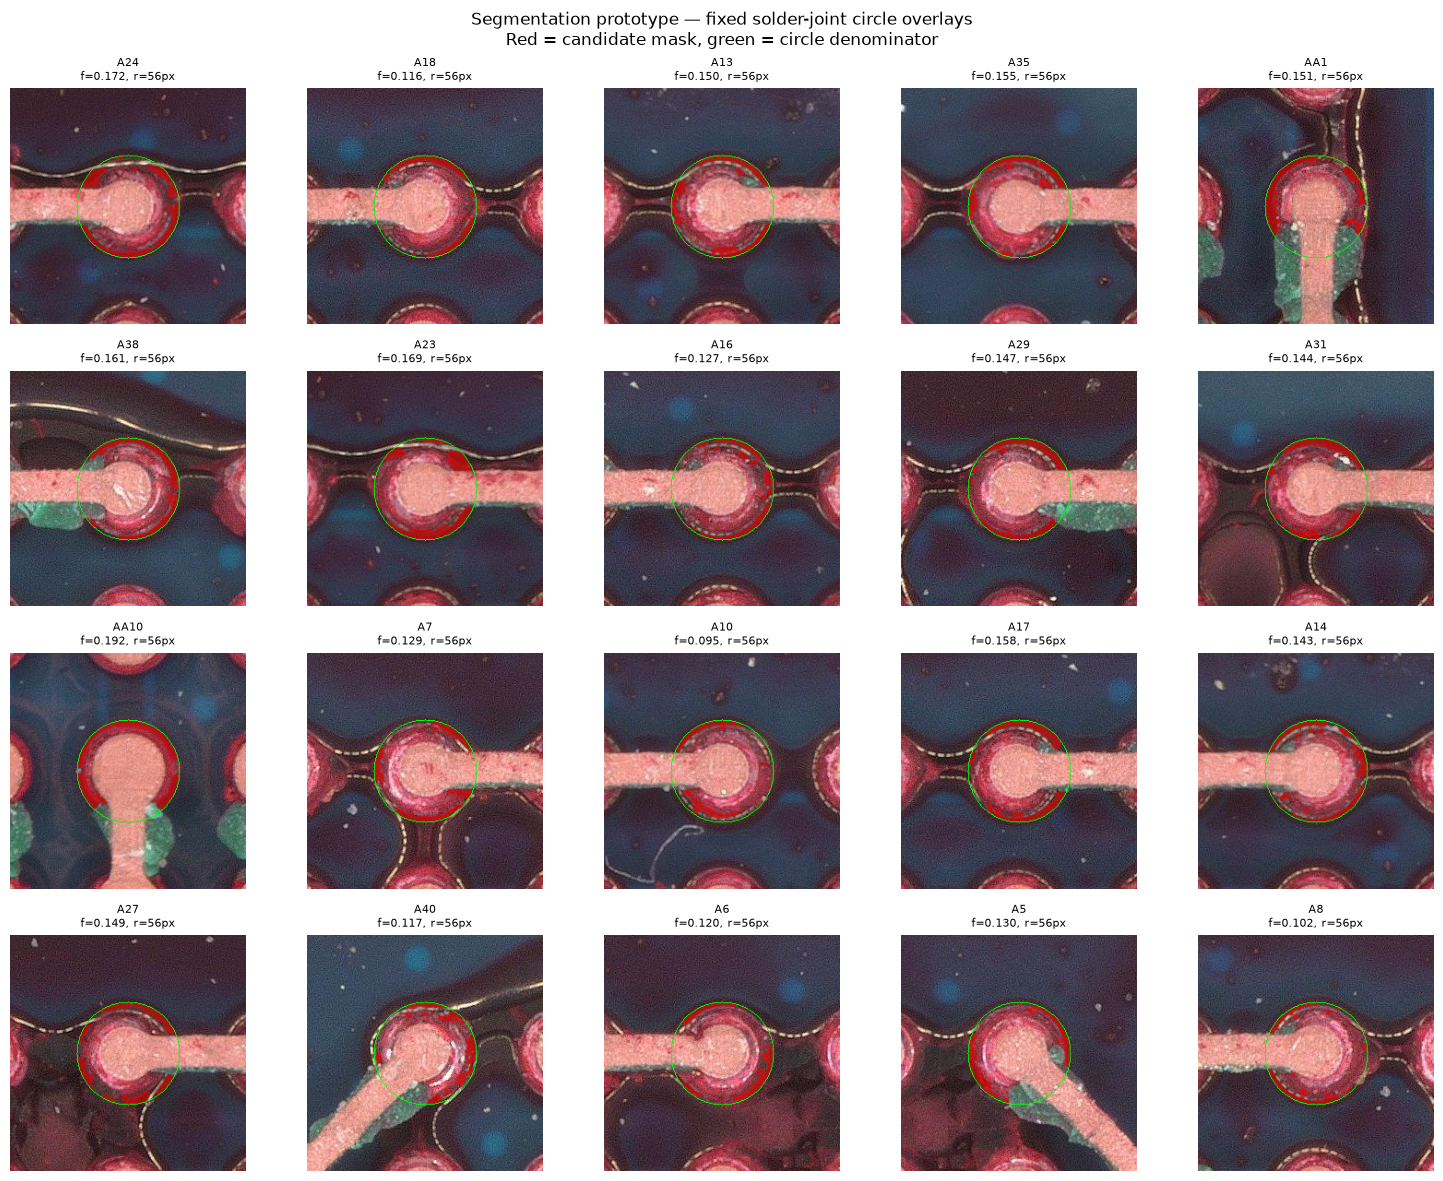

Saved 20 circle-mask overlay PNGs to output\segmentation_overlays\FP11_2_X20


In [7]:
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for ax, res in zip(axes, seg_results):
    overlay = overlay_mask(res["roi"], res["heuristic_mask"], JOINT_MASK)
    ax.imshow(overlay)
    ax.set_title(f"{res['ball_id']}\nf={res['heuristic_fraction']:.3f}, r={JOINT_RADIUS}px", fontsize=8)
    ax.axis("off")

for ax in axes[len(seg_results):]:
    ax.axis("off")

plt.suptitle(
    "Segmentation prototype — fixed solder-joint circle overlays\n"
    "Red = candidate mask, green = circle denominator",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Remove stale overlays from earlier runs so the folder reflects the current method.
for old in OVERLAY_DIR.glob("*_heuristic_overlay.png"):
    old.unlink()

for res in seg_results:
    overlay = overlay_mask(res["roi"], res["heuristic_mask"], JOINT_MASK)
    cv2.imwrite(str(OVERLAY_DIR / f"{res['ball_id']}_heuristic_overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print(f"Saved {len(seg_results)} circle-mask overlay PNGs to {OVERLAY_DIR.relative_to(REPO_ROOT)}")

## 7. Compare ROI, heuristic mask, and U-Net mask on a few examples


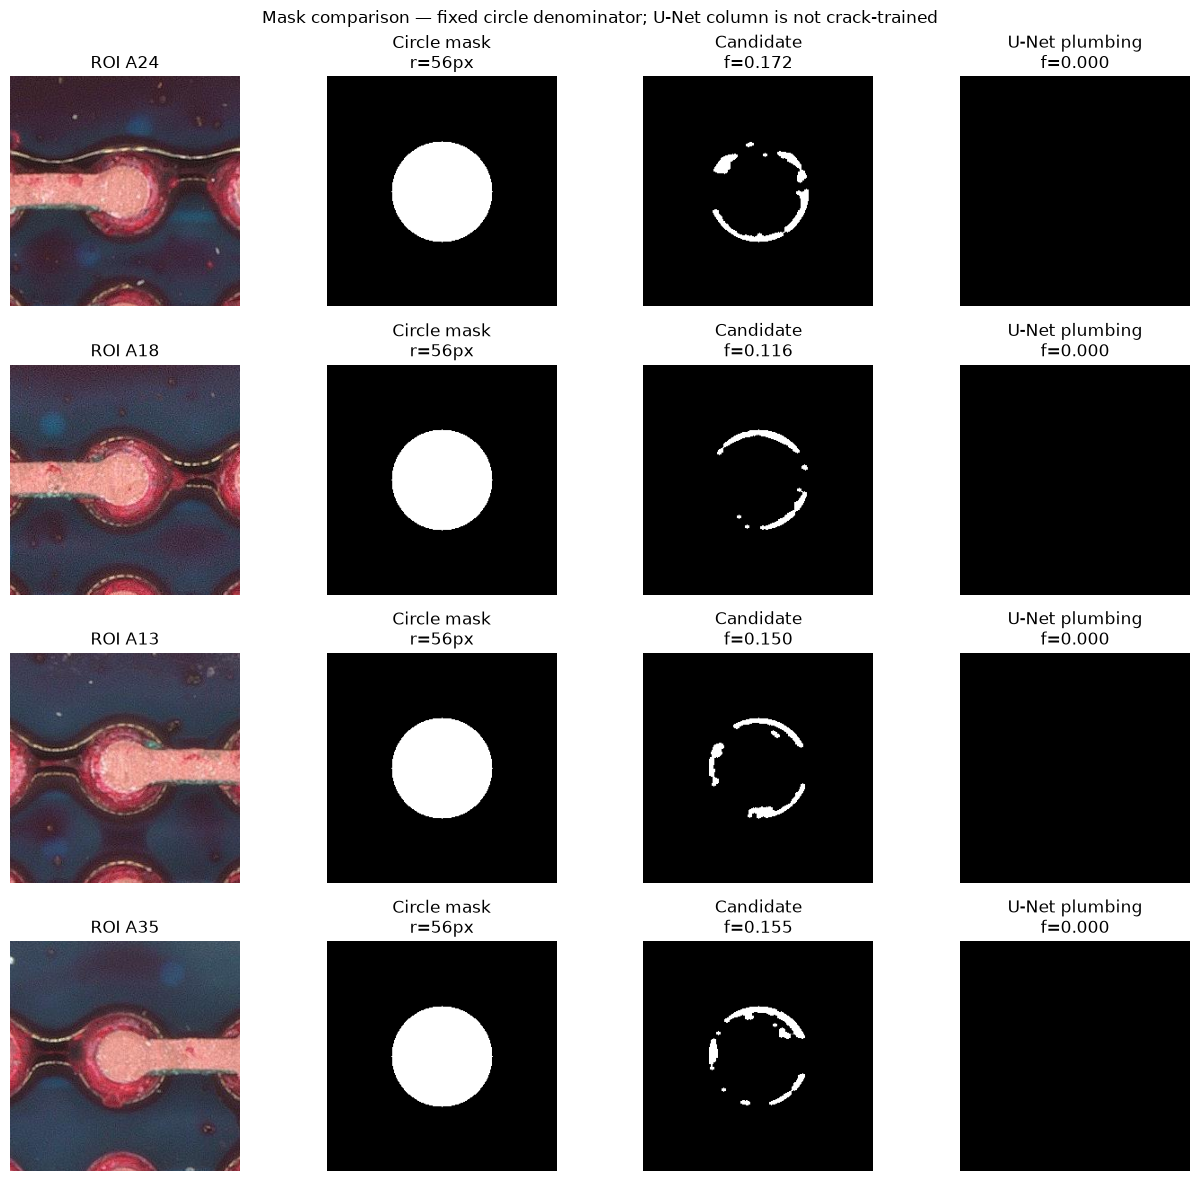

In [8]:
compare_n = min(4, len(seg_results))
fig, axes = plt.subplots(compare_n, 4, figsize=(13, 3 * compare_n))
if compare_n == 1:
    axes = np.array([axes])

for row, res in zip(axes, seg_results[:compare_n]):
    roi_rgb = cv2.cvtColor(res["roi"], cv2.COLOR_BGR2RGB)
    row[0].imshow(roi_rgb)
    row[0].set_title(f"ROI {res['ball_id']}")
    row[0].axis("off")

    row[1].imshow(JOINT_MASK, cmap="gray")
    row[1].set_title(f"Circle mask\nr={JOINT_RADIUS}px")
    row[1].axis("off")

    row[2].imshow(res["heuristic_mask"], cmap="gray")
    row[2].set_title(f"Candidate\nf={res['heuristic_fraction']:.3f}")
    row[2].axis("off")

    if res["unet_mask"] is not None:
        row[3].imshow(res["unet_mask"], cmap="gray")
        row[3].set_title(f"U-Net plumbing\nf={res['unet_fraction']:.3f}")
    else:
        row[3].text(0.5, 0.5, "U-Net unavailable", ha="center", va="center")
        row[3].set_title("U-Net")
    row[3].axis("off")

plt.suptitle("Mask comparison — fixed circle denominator; U-Net column is not crack-trained", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Automated prototype gates (Test 4.4 mechanics)


In [9]:
print("=" * 72)
print("TEST 4.4 — SEGMENTATION PROTOTYPE MECHANICS")
print("=" * 72)

gate_rois = len(sample_records) > 0 and all(r["roi"].shape == (ROI_SIZE, ROI_SIZE, 3) for r in sample_records)
print(f"[{'PASS' if gate_rois else 'FAIL'}] Gate 1: sample ROIs loaded with shape {ROI_SIZE}×{ROI_SIZE}×3")

gate_unet = bool(unet_gate_ok)
print(f"[{'PASS' if gate_unet else 'REVIEW'}] Gate 2: U-Net forward pass shape {unet_output_shape}")

gate_joint = JOINT_MASK.shape == (ROI_SIZE, ROI_SIZE) and JOINT_MASK.dtype == bool and 35 <= JOINT_RADIUS <= 75
print(f"[{'PASS' if gate_joint else 'REVIEW'}] Gate 3: fixed solder-joint circle mask is plausible (r={JOINT_RADIUS}px)")

gate_masks = all(r["heuristic_mask"].shape == (ROI_SIZE, ROI_SIZE) and r["heuristic_mask"].dtype == bool for r in seg_results)
print(f"[{'PASS' if gate_masks else 'FAIL'}] Gate 4: heuristic masks are binary {ROI_SIZE}×{ROI_SIZE}")

gate_fraction = bool(np.isfinite(fractions).all() and ((fractions >= 0) & (fractions <= 1)).all())
print(f"[{'PASS' if gate_fraction else 'FAIL'}] Gate 5: crack fractions finite and in [0, 1]")

gate_overlays = OVERLAY_DIR.exists() and len(list(OVERLAY_DIR.glob("*_heuristic_overlay.png"))) == len(seg_results)
print(f"[{'PASS' if gate_overlays else 'FAIL'}] Gate 6: circle-mask overlay PNGs saved for visual review")

all_mechanics = gate_rois and gate_joint and gate_masks and gate_fraction and gate_overlays
print("=" * 72)
print("PASS — circle-mask segmentation mechanics validated; accuracy awaits labels/fine-tuning." if all_mechanics else "REVIEW — one or more mechanics gates failed.")
print("=" * 72)
print("NOTE: U-Net gate is separate from mechanics because online ImageNet weight download may be unavailable.")

TEST 4.4 — SEGMENTATION PROTOTYPE MECHANICS
[PASS] Gate 1: sample ROIs loaded with shape 256×256×3
[PASS] Gate 2: U-Net forward pass shape (256, 256)
[PASS] Gate 3: fixed solder-joint circle mask is plausible (r=56px)
[PASS] Gate 4: heuristic masks are binary 256×256
[PASS] Gate 5: crack fractions finite and in [0, 1]
[PASS] Gate 6: circle-mask overlay PNGs saved for visual review
PASS — circle-mask segmentation mechanics validated; accuracy awaits labels/fine-tuning.
NOTE: U-Net gate is separate from mechanics because online ImageNet weight download may be unavailable.


## 9. Summary

**Outputs consumed by `05_classification.ipynb`:**

- `JOINT_MASK` / `circle_mask()` — fixed circle denominator selected by visual review.
- `heuristic_crack_candidate_mask()` — temporary deterministic candidate mask until a trained crack model exists.
- `compute_crack_fraction()` — fraction of solder-joint circle pixels marked by a binary mask.
- `seg_results` — sample records containing ROIs, candidate masks, and crack-fraction values.
- Circle-mask overlay PNGs saved under `output/segmentation_overlays/<image_stem>/` for visual review.

**What is validated here:**

- ROI loading and preprocessing work.
- A U-Net-style model can be constructed and, when available, run on the ROI tensor shape.
- The denominator is now a fixed circle mask that visually envelopes the solder joint better than the temporary adaptive mask.
- Binary masks can be post-processed, overlaid, and converted to crack-fraction values.

**What is not validated yet:**

- Crack-segmentation accuracy. There is no ground-truth labelled crack mask or trained checkpoint yet.
- Category accuracy. Step 1.4 manual labels and later fine-tuning are still needed before production use.

**Next step:** `05_classification.ipynb` can demonstrate threshold mapping from crack fraction to A–E categories, while keeping the same prototype caveat until labelled data is available.